In [1]:
import numpy as np
import sys
import os
import VBMicrolensing
import emcee
import h5py
import math
import matplotlib.pyplot as plt
import concurrent.futures
import corner
from tqdm import tqdm
VBM = VBMicrolensing.VBMicrolensing()
JD0 = 2450000
from matplotlib.lines import Line2D
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
import EarthMotion
import parametrics
from matplotlib.lines import Line2D


import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap

In [2]:
tref = 10063.874
    
RA_str,Dec_str = "18:03:24.57","-30:02:34.48"
RA_deg = EarthMotion.hms_string_to_degrees(RA_str)
Dec_deg = EarthMotion.dms_string_to_degrees(Dec_str)
vEarth = EarthMotion.calc_vEarth(tref,RA_deg,Dec_deg)

gapmoe_model = gapmoe(RA_deg,Dec_deg)
gapmoe_model.set_data()

In [3]:
import matplotlib as mpl
mpl.rc('font', **{'family': 'serif', 'serif': ['Liberation Serif', 'DejaVu Serif']})
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 15,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "0.3",
    "axes.linewidth": 1.4,
    "grid.alpha": 0.25,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [4]:
labels_phys_muEN = [
    r"$M_{\rm L} M_\odot)$",
    r"$D_{\rm L} {\rm kpc})$",
    r"$D_{\rm S} {\rm kpc})$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$"
]

In [5]:
column_names = " wtj          M_L   D_L   D_S          t_E      theta_E         pi_E         pi_EN         pi_EE       mu_rel        mu_Sl        mu_Sb     I_L iS iL fREM".strip().split()

base_path = "/moao38_7/nunota/genulens_out_nishio.dat"

column_names = " wtj          M_L   D_L   D_S          t_E      theta_E         pi_E         pi_EN         pi_EE       mu_rel        mu_Sl        mu_Sb     I_L iS iL fREM".strip().split()
column_names = ["wtj","M_L","D_L","D_S","piE","piEN","piEE","murel"]
use_cols = [0,1,2,3,6,7,8,9]
data = np.genfromtxt(base_path, names=column_names,usecols=use_cols)

use_ind = np.where(
    (data["M_L"] <= 1.5) &
    (data["D_L"] >= 0) & (data["D_L"] <= 12000) &
    (data["D_S"] >= 0) & (data["D_S"] <= 16000) &
    (data["murel"] >= -50) & (data["murel"] <= 50)
)

data = data[use_ind]

data_muE = data["murel"] * data["piEE"] / data["piE"]
data_muN = data["murel"] * data["piEN"] / data["piE"]

plot_data = np.array([data["M_L"],data["D_L"],data["D_S"],data_muN,data_muE])

In [6]:
def log_prior_for_emcee(params, gapmoe_model):
    ML, DL, DS, muN, muE = params
    mu = np.sqrt(muN**2 + muE**2)
    phi = np.arctan2(muE,muN)
    
    
    if not (gapmoe_model.M_MIN <= ML <= gapmoe_model.M_MAX):
        return -np.inf
    if not (gapmoe_model.DL_MIN <= DL < gapmoe_model.DL_MAX):
        return -np.inf
    if not (gapmoe_model.DS_MIN <= DS < gapmoe_model.DS_MAX):
        return -np.inf
    if DL >= DS:
        return -np.inf
    if not (gapmoe_model.MU_MIN <= mu < gapmoe_model.MU_MAX):
        return -np.inf
    
    return gapmoe_model.log_galactic_prior(ML, DL, DS, mu, phi) - np.log(mu)

In [7]:
# ndim = 5  # [ML, DL, DS, muN, muE]
# nwalkers = 32  # walker数（推奨: 2×ndim 以上）

# # 初期位置をランダムにばらけさせる
# p0 = np.random.rand(nwalkers, ndim)
# p0[:, 0] = gapmoe_model.M_MIN + p0[:, 0] * (0.5 - 0.4)  # ML
# p0[:, 1] = gapmoe_model.DL_MIN + p0[:, 1] * (7500 - 6500)  # DL
# p0[:, 2] = gapmoe_model.DS_MIN + p0[:, 2] * (8500 - 7500)  # DS
# p0[:, 3] = (p0[:, 3] - 0.5)*10
# p0[:, 4] = (p0[:, 4] - 0.5)*10

# sampler = emcee.EnsembleSampler(nwalkers, ndim, lambda p: log_prior_for_emcee(p, gapmoe_model))
# sampler.run_mcmc(p0, 100000, progress=True)

# samples = sampler.get_chain(discard=100, thin=10, flat=True)

samples = np.load("/moao38_7/nunota/gapmoe_out_nishio.npy")

In [8]:
samples_nf = np.genfromtxt("/moao38_7/nunota/gapmoe/test_gal_result/nf_samples_jax.dat")
teachar_data = np.genfromtxt("/moao38_7/nunota/gapmoe/test_gal_result/data_5d.dat")

In [9]:
teachar_data.shape

(1000000, 5)

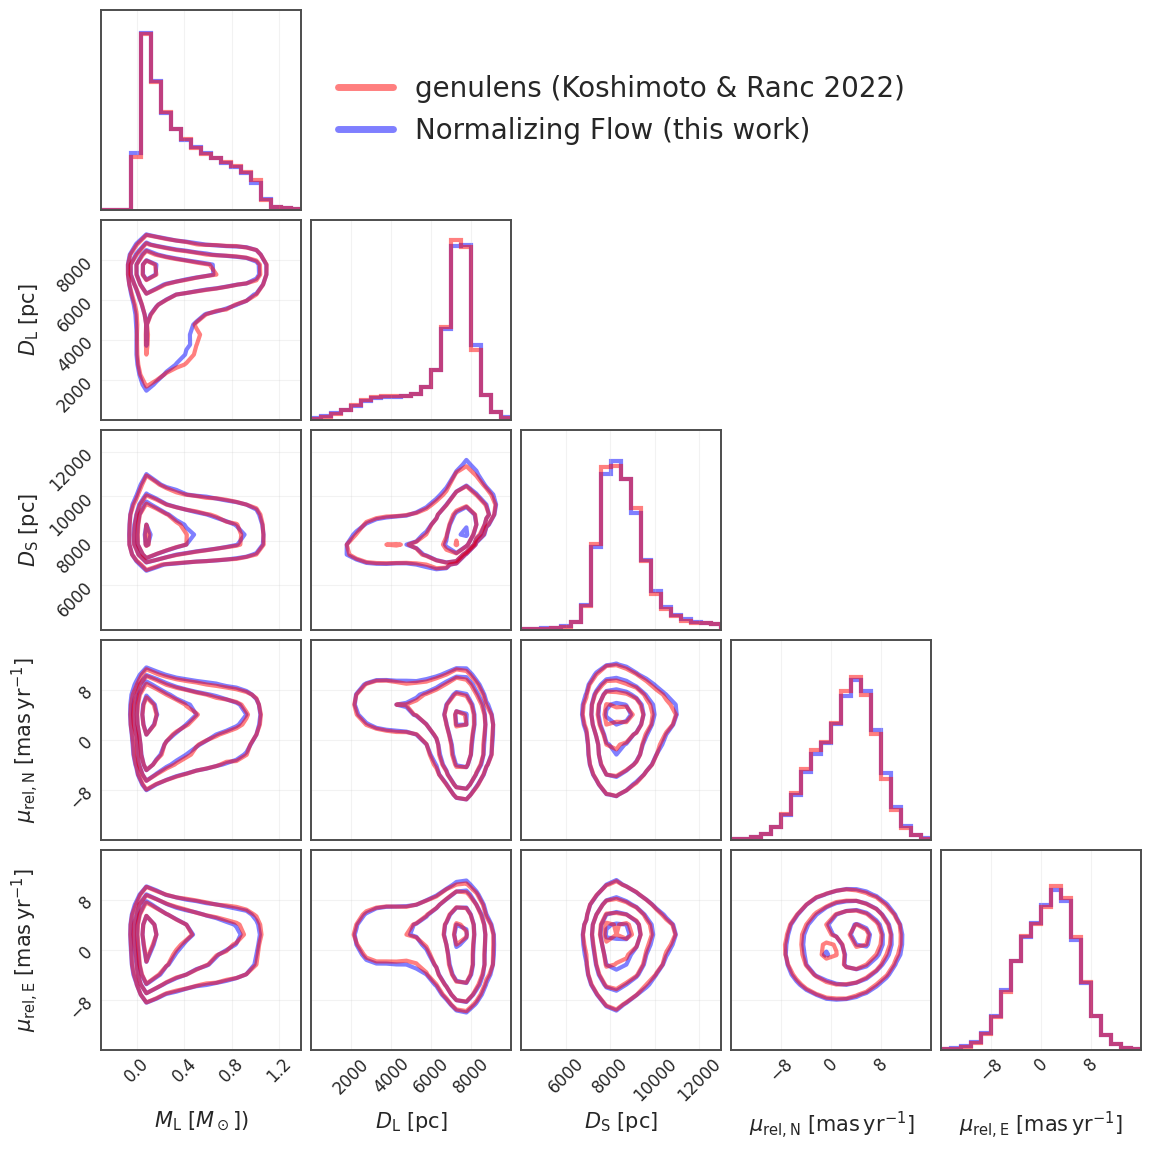

In [10]:
ranges = [
    (-0.3,1.39), 
    (0, 9999),      # logDL
    (4000, 13000),      # logDS
    (-16, 16-0.01),         # mu_rel_N
    (-16, 16-0.01)        # mu_rel_E
]


# 図作成
use_ind = np.where(np.sqrt(plot_data[3]**2 + plot_data[4]**2)<16)[0]
fig = corner.corner(
    plot_data[:,use_ind].T,
    weights=data["wtj"][use_ind],
    color="r",
    hist_kwargs={"density": True, "linewidth": 3, "alpha": 0.5},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 6, "linewidths": 3,"alpha":0.5},
    fill_contours=False,no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
#     smooth=1.0,
    range=ranges
)

# corner.corner(
#     samples,
#     labels=[r"$M_{\rm L}~[M_\odot])$", r"$D_{\rm L}~[\mathrm{pc}]$", r"$D_{\rm S}~[\mathrm{pc}]$", r"$\mu_{\rm rel,N}~[\mathrm{mas\,yr^{-1}}]$", r"$\mu_{\rm rel,E}~[\mathrm{mas\,yr^{-1}}]$"],
#     fig=fig,
#     color="C1",
#     hist_kwargs={"density": True, "linewidth": 3, "alpha": 1,"zorder":0},
#     contour_kwargs={"zorder": 4, "linewidths": 3,"alpha":1},
#     fill_contours=False,
#     no_fill_contours=True,
#     show_titles=False,
#     plot_density=False,
#     plot_datapoints=False,
# #     smooth=1.0,
#     range=ranges
# )

corner.corner(
    samples_nf,
    labels=[r"$M_{\rm L}~[M_\odot])$", r"$D_{\rm L}~[\mathrm{pc}]$", r"$D_{\rm S}~[\mathrm{pc}]$", r"$\mu_{\rm rel,N}~[\mathrm{mas\,yr^{-1}}]$", r"$\mu_{\rm rel,E}~[\mathrm{mas\,yr^{-1}}]$"],
    fig=fig,
    color="b",
    hist_kwargs={"density": True, "linewidth": 3, "alpha": 0.5,"zorder":0},
    contour_kwargs={"zorder": 5, "linewidths": 3,"alpha":0.5},
    fill_contours=False,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
#     smooth=1.0,
    range=ranges
)

from matplotlib.patches import Patch
handles = [
    Line2D([],[],color='r', label=r'genulens (Koshimoto & Ranc 2022)', lw=5,alpha=0.5),
#     Line2D([],[],color='C1', label='gapmoe (Nunota & Masuda in prep.)', lw=5,),
    Line2D([],[],color='b', label='Normalizing Flow (this work)', lw=5,alpha=0.5)
]

# fig.legend(handles=handles, loc='upper right', fontsize=20, frameon=False)
ndim = 5
axes = np.array(fig.axes).reshape((ndim, ndim))
axes[0, 2].legend(
    handles=handles,
    fontsize=20,
    loc="center",
    frameon=False,
)

ndim = samples.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))
diag_ylims = [2.5,0.0005,0.0005,0.11,0.11]
for i in range(ndim):
    ax = axes[i, i]
    ax.set_ylim(bottom=0)
    ax.set_ylim(top=diag_ylims[i])  

plt.savefig("/moao38_7/nunota/FlowJalaxy/figures/comp_genu_flow.pdf")
plt.show()

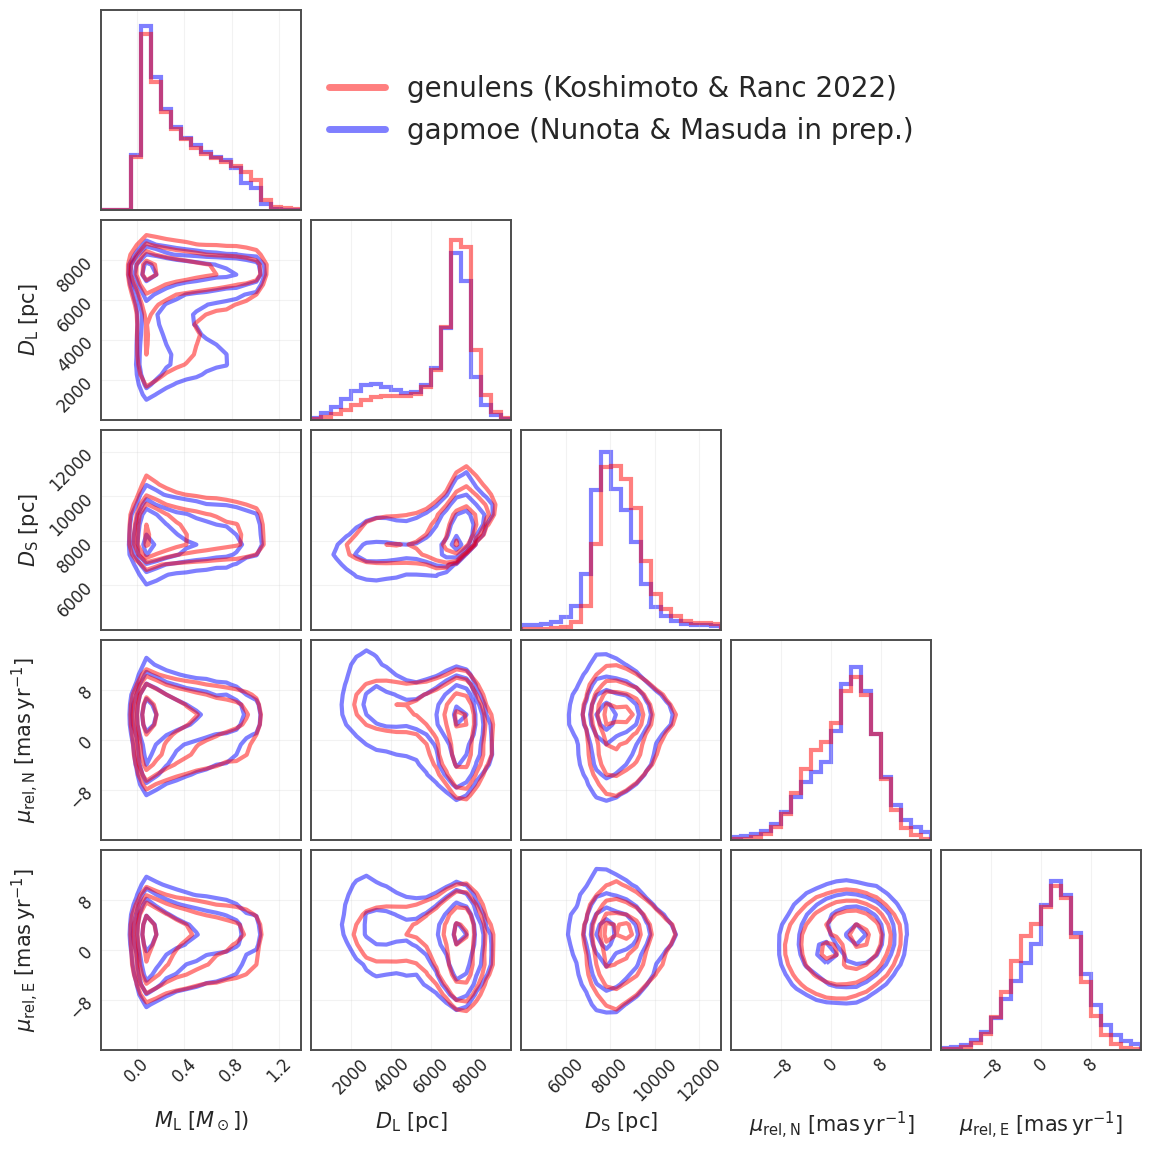

In [11]:
ranges = [
    (-0.3,1.39), 
    (0, 9999),      # logDL
    (4000, 13000),      # logDS
    (-16, 16-0.01),         # mu_rel_N
    (-16, 16-0.01)        # mu_rel_E
]


# 図作成
use_ind = np.where(np.sqrt(plot_data[3]**2 + plot_data[4]**2)<16)[0]
fig = corner.corner(
    plot_data[:,use_ind].T,
    weights=data["wtj"][use_ind],
    color="r",
    hist_kwargs={"density": True, "linewidth": 3, "alpha": 0.5},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 6, "linewidths": 3,"alpha":0.5},
    fill_contours=False,no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
#     smooth=1.0,
    range=ranges
)

corner.corner(
    samples,
    labels=[r"$M_{\rm L}~[M_\odot])$", r"$D_{\rm L}~[\mathrm{pc}]$", r"$D_{\rm S}~[\mathrm{pc}]$", r"$\mu_{\rm rel,N}~[\mathrm{mas\,yr^{-1}}]$", r"$\mu_{\rm rel,E}~[\mathrm{mas\,yr^{-1}}]$"],
    fig=fig,
    color="b",
    hist_kwargs={"density": True, "linewidth": 3, "alpha": 0.5,"zorder":0},
    contour_kwargs={"zorder": 4, "linewidths": 3,"alpha":0.5},
    fill_contours=False,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
#     smooth=1.0,
    range=ranges
)

# corner.corner(
#     samples_nf,
#     labels=[r"$M_{\rm L}~[M_\odot])$", r"$D_{\rm L}~[\mathrm{pc}]$", r"$D_{\rm S}~[\mathrm{pc}]$", r"$\mu_{\rm rel,N}~[\mathrm{mas\,yr^{-1}}]$", r"$\mu_{\rm rel,E}~[\mathrm{mas\,yr^{-1}}]$"],
#     fig=fig,
#     color="C1",
#     hist_kwargs={"density": True, "linewidth": 3, "alpha": 0.5,"zorder":0},
#     contour_kwargs={"zorder": 5, "linewidths": 3,"alpha":0.5},
#     fill_contours=False,
#     no_fill_contours=True,
#     show_titles=False,
#     plot_density=False,
#     plot_datapoints=False,
# #     smooth=1.0,
#     range=ranges
# )

from matplotlib.patches import Patch
handles = [
    Line2D([],[],color='r', label=r'genulens (Koshimoto & Ranc 2022)', lw=5,alpha=0.5),
    Line2D([],[],color='b', label='gapmoe (Nunota & Masuda in prep.)', lw=5,alpha=0.5),
#     Line2D([],[],color='C1', label='gapmoe (Normalising Flow (this work))', lw=5,)
]

# fig.legend(handles=handles, loc='upper right', fontsize=20, frameon=False)
ndim = 5
axes = np.array(fig.axes).reshape((ndim, ndim))
axes[0, 2].legend(
    handles=handles,
    fontsize=20,
    loc="center",
    frameon=False,
)

ndim = samples.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))
diag_ylims = [2.5,0.0005,0.0005,0.11,0.11]
for i in range(ndim):
    ax = axes[i, i]
    ax.set_ylim(bottom=0)
    ax.set_ylim(top=diag_ylims[i])  

plt.savefig("/moao38_7/nunota/FlowJalaxy/figures/comp_genu_gap.pdf")
plt.show()

In [14]:
samples_nf_galaxia = np.genfromtxt("/moao38_7/nunota/gapmoe/test_gal_result/nf_galaxia_samples.dat")
teachar_data_galaxia = np.load("/moao38_7/nunota/PopSyCLE/samples/sample_nishio.npy")

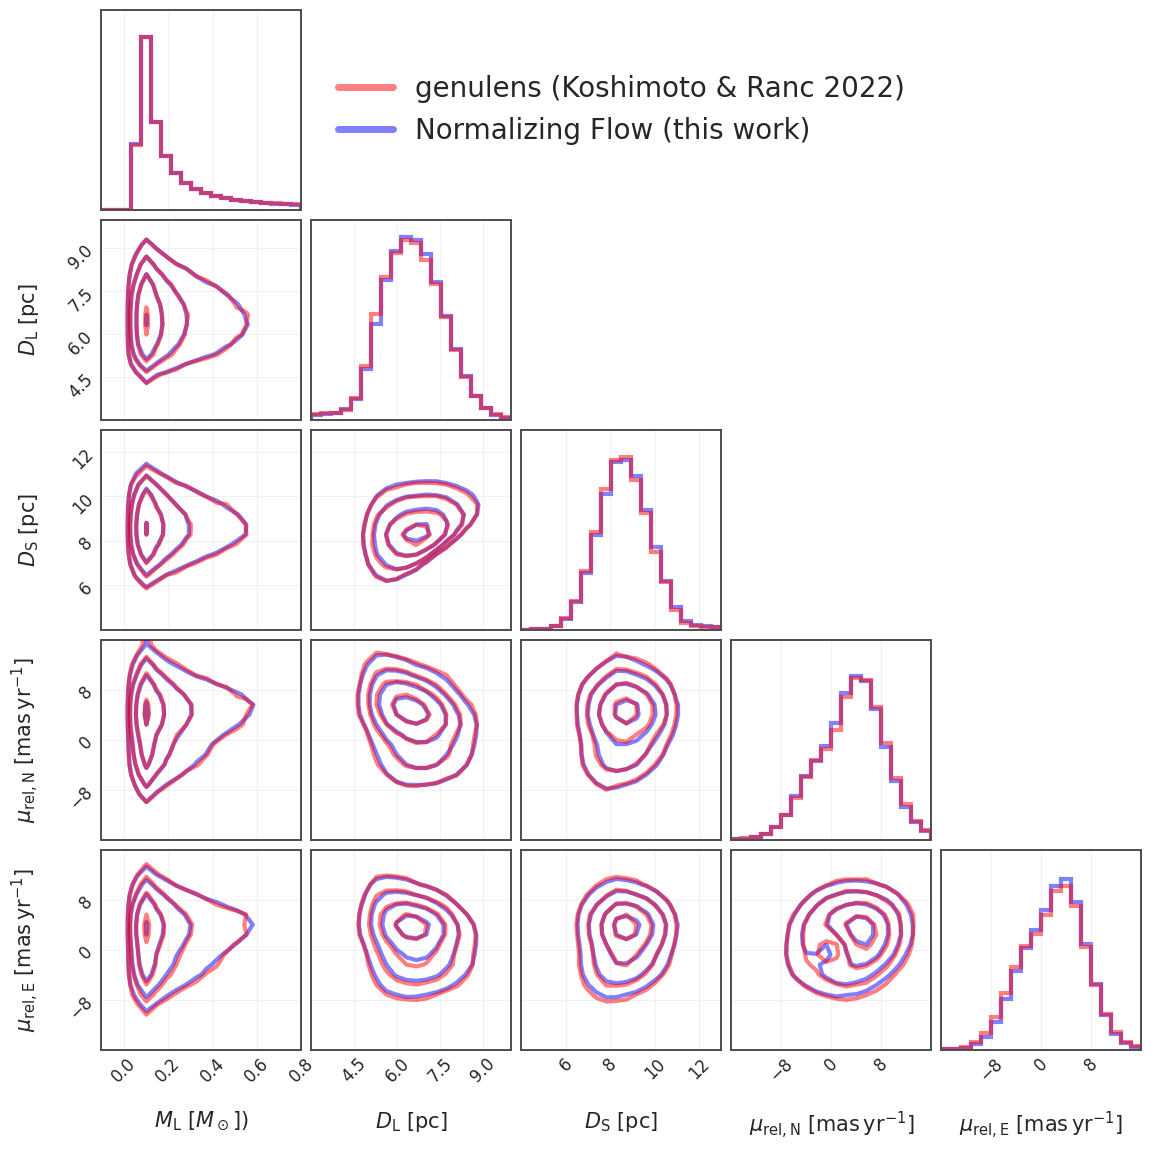

In [35]:
ranges = [
    (-0.1,0.8), 
    (3, 9.999),      # logDL
    (4, 13),      # logDS
    (-16, 16-0.01),         # mu_rel_N
    (-16, 16-0.01)        # mu_rel_E
]

fig = corner.corner(
    teachar_data_galaxia[:,:],
    color="r",
    hist_kwargs={"density": True, "linewidth": 3, "alpha": 0.5},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 6, "linewidths": 3,"alpha":0.5},
    fill_contours=False,no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
#     smooth=1.0,
    range=ranges
)

corner.corner(
    samples_nf_galaxia[:,:],
    labels=[r"$M_{\rm L}~[M_\odot])$", r"$D_{\rm L}~[\mathrm{pc}]$", r"$D_{\rm S}~[\mathrm{pc}]$", r"$\mu_{\rm rel,N}~[\mathrm{mas\,yr^{-1}}]$", r"$\mu_{\rm rel,E}~[\mathrm{mas\,yr^{-1}}]$"],
    fig=fig,
    color="b",
    hist_kwargs={"density": True, "linewidth": 3, "alpha": 0.5,"zorder":0},
    contour_kwargs={"zorder": 5, "linewidths": 3,"alpha":0.5},
    fill_contours=False,
    no_fill_contours=True,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
#     smooth=1.0,
    range=ranges
)

from matplotlib.patches import Patch
handles = [
    Line2D([],[],color='r', label=r'genulens (Koshimoto & Ranc 2022)', lw=5,alpha=0.5),
#     Line2D([],[],color='C1', label='gapmoe (Nunota & Masuda in prep.)', lw=5,),
    Line2D([],[],color='b', label='Normalizing Flow (this work)', lw=5,alpha=0.5)
]

# fig.legend(handles=handles, loc='upper right', fontsize=20, frameon=False)
ndim = 5
axes = np.array(fig.axes).reshape((ndim, ndim))
axes[0, 2].legend(
    handles=handles,
    fontsize=20,
    loc="center",
    frameon=False,
)

ndim = samples.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))
diag_ylims = [8.,0.4,0.4,0.1,.1]
for i in range(ndim):
    ax = axes[i, i]
    ax.set_ylim(bottom=0)
    ax.set_ylim(top=diag_ylims[i])

plt.savefig("/moao38_7/nunota/FlowJalaxy/figures/comp_genu_flow_galaxia.pdf")
plt.show()